# Multi-Feature Linear Regression with Gradient Descent — Real Kaggle Data

From-scratch (vectorized) gradient descent on the real-world **Salary** dataset.

Dataset: *Salary Data* (Kaggle: `mohithsairamreddy/salary-data`) — ~6,700 rows with `Age`, `Gender`, `Education Level`, `Job Title`, `Years of Experience` → `Salary`.

**What this notebook handles (because real data is messy):**
- **Missing values** — a few rows have `NaN`; we `dropna()` them (otherwise `mean`/`std` return `NaN` and poison everything).
- **Dirty labels** — `Education Level` mixes `Bachelor's`/`Bachelor's Degree`, `PhD`/`phD`, etc.; we normalize them.
- **Categorical text** — `Gender`, `Education Level`, `Job Title` are one-hot encoded (they can't be standardized as numbers).
- **Scaling** — we standardize only the numeric columns (`Age`, `Years of Experience`) and the target `y`; the 0/1 dummy columns are left as-is.

The model is **multi-feature**, so `w` is a weight *vector* and predictions are `X @ w + b`.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import kagglehub

In [20]:
# Download latest version
path = kagglehub.dataset_download("mohithsairamreddy/salary-data")

print("Path to dataset files:", path)
df = pd.read_csv(f"{path}/Salary_Data.csv")
print("Shape:", df.shape)
df.head()

Path to dataset files: C:\Users\91720\.cache\kagglehub\datasets\mohithsairamreddy\salary-data\versions\4
Shape: (6704, 6)


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [ ]:
# =====================================
# Clean + build features (all columns)
# =====================================
df = df.dropna().copy()                       # 1) drop the few rows with missing values

# 2) fix inconsistent Education labels
df["Education Level"] = df["Education Level"].replace({
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree":   "Master's",
    "phD":               "PhD",
})

num_cols = ["Age", "Years of Experience"]
cat_cols = ["Gender", "Education Level", "Job Title"]

# 3) one-hot encode categoricals (.astype(float) — get_dummies returns bool)
X_num = df[num_cols].astype(float)
X_cat = pd.get_dummies(df[cat_cols], drop_first=True).astype(float)
X_all = pd.concat([X_num, X_cat], axis=1)
y = df["Salary"].values.astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X_all.values, y, test_size=0.2, random_state=42
)
n = len(X_train)

# =====================================
# Feature Scaling (Standardization)
# Standardize NUMERIC columns + y only; leave the 0/1 dummies as-is.
# Fit on TRAIN data only, then apply to both sets.
# =====================================
n_num = len(num_cols)
X_mean = X_train[:, :n_num].mean(axis=0)
X_std  = X_train[:, :n_num].std(axis=0)
y_mean, y_std = y_train.mean(), y_train.std()

X_train_s = X_train.copy()
X_test_s  = X_test.copy()
X_train_s[:, :n_num] = (X_train[:, :n_num] - X_mean) / X_std
X_test_s[:,  :n_num] = (X_test[:,  :n_num] - X_mean) / X_std
y_train_s = (y_train - y_mean) / y_std

print("Feature matrix shape:", X_all.shape)
print("Any NaN in X_train_s?", np.isnan(X_train_s).any())

In [ ]:
# =====================================
# Vectorized Gradient Descent (multi-feature)
# w is now a vector; predictions are X @ w + b
# =====================================
d = X_train_s.shape[1]
w = np.zeros(d)
b = 0.0

lr = 0.1
epochs = 2000

costs = []

for epoch in range(epochs):

    y_pred = X_train_s @ w + b
    err = y_train_s - y_pred
    cost = np.mean(err ** 2)
    costs.append(cost)

    # Gradients (sign of -2/n folded into the update below)
    w = w + lr * (2 / n) * (X_train_s.T @ err)
    b = b + lr * (2 / n) * err.sum()

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss={cost:.4f}")

print("\nTraining Complete")
print(f"Learned {d} weights (one per feature) + 1 bias")
print(f"Final Bias (b): {b:.4f}")

In [ ]:
# =====================================
# Predictions (convert back to original $ units)
# =====================================
y_test_pred_s = X_test_s @ w + b
y_test_pred = y_test_pred_s * y_std + y_mean   # inverse standardization

# =====================================
# Evaluation Metrics (original units)
# =====================================
mae  = np.mean(np.abs(y_test - y_test_pred))
mse  = np.mean((y_test - y_test_pred) ** 2)
rmse = np.sqrt(mse)

ss_res = np.sum((y_test - y_test_pred) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print("Evaluation Metrics (all features)")
print(f"MAE  = {mae:.2f}")
print(f"MSE  = {mse:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"R²   = {r2:.4f}")

# =====================================
# Top feature weights (in standardized space)
# Larger |weight| = stronger pull on salary.
# =====================================
weights = pd.Series(w, index=X_all.columns)
print("\nTop 10 features by |weight|:")
print(weights.reindex(weights.abs().sort_values(ascending=False).index).head(10))

# A few sample predictions
print("\nSample Test Predictions")
for actual, pred in list(zip(y_test, y_test_pred))[:15]:
    print(f"Actual: {actual:10.2f}  Predicted: {pred:10.2f}")

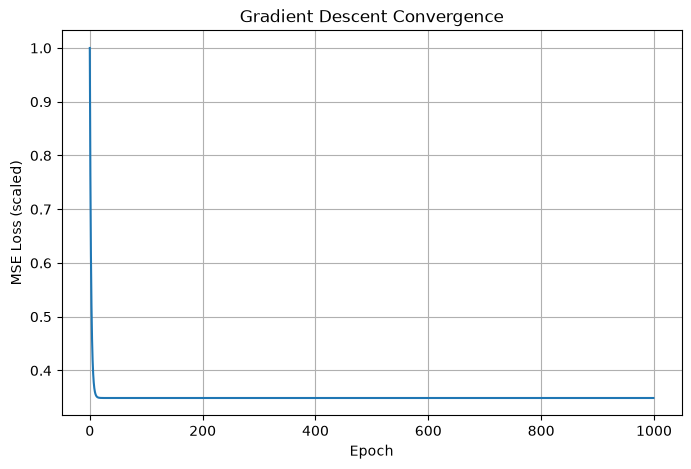

In [16]:
# =====================================
# Loss Curve
# =====================================
plt.figure(figsize=(8,5))
plt.plot(costs)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled)")
plt.title("Gradient Descent Convergence")
plt.grid(True)
plt.show()

In [ ]:
# =====================================
# Actual vs Predicted
# (multi-feature model can't be drawn as one line, so we
#  plot predicted vs actual; perfect predictions lie on y = x)
# =====================================
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_test_pred, alpha=0.4, label="Test predictions")

lims = [min(y_test.min(), y_test_pred.min()),
        max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction (y = x)")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"Actual vs Predicted — Multi-Feature Linear Regression (R² = {r2:.3f})")
plt.legend()
plt.grid(True)
plt.show()